In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

from typing import Tuple, Dict, List, Optional, Union

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import gaussoptfuncs

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251210_082542.log


In [2]:
from skimage.filters import gaussian, median

In [3]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
print(np.median(gain))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
print(np.median(offset))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
print(np.median(variance))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
print(np.median(readnoise))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

0.414377
32.3464
0.937415
2.33717


In [17]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 10
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), 1)
camera_parameters["offset"] = np.full((image_size, image_size), 30)
camera_parameters["variance"] = np.full((image_size, image_size), 1e-3)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-3)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
camera_parameters["pixel_QYs"] = np.vstack([B, G, R])
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
masks = M_F.get_masks(size_x=image_size, size_y=image_size)

camera_parameters["masks"] = masks
# camera_parameters["masks"] = masks

In [20]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter = "semrock-blp01-635r"
longpass_green_filter = "semrock-blp02-561r"
bandpass_green_filter = "semrock-ff01-582-64"
longpass_blue_filter = "semrock-blp01-488r"
bandpass_blue_filter = "semrock-ff01-520-44"
filters = [dichroic_mirror, notch_filter]
dyes = ["ATTO 565"]
_, dye_library = S_F.get_pixel_fractions_dye_and_filters(
    dyes,
    filters,
    wavelength,
    camera_parameters["pixel_QYs"],
)

In [21]:
ATTO488 = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 488'], wavelength=wavelength))
ATTO565 = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 565'], wavelength=wavelength))
ATTO594 = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 594'], wavelength=wavelength))
ATTO647N = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 647N'], wavelength=wavelength))

In [22]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [23]:
pixel_size = 69
physical_image_size = pixel_size * np.array(camera_parameters["gain"].shape)

In [24]:
physical_image_size

array([690, 690])

In [68]:
x = np.array([0.5])
y = np.array([0.5])

In [69]:
positions = np.array([(x), (y)]).T * physical_image_size
X0, Y0 = np.meshgrid(positions[:, 0], positions[:, 1])
X0 = X0.ravel()
Y0 = Y0.ravel()

In [70]:
X0

array([ 345.])

In [71]:
x0y0 = {}
n_photons = {}
n_ph = 2000
for i, dye in enumerate(dyes):
    
    NA = 1.49
    s = 1
    n_photons[dye] = np.full(s, n_ph)
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[X0[i], Y0[i]]]).T


In [65]:
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dyes, filters, wavelength, camera_parameters["pixel_QYs"], normalized=False)
)

In [66]:
background_photons = int(5)
bayer_image_example, smoothed_image, _ = MSF.gen_camera_image_stack(
    camera_parameters,
    wavelength,
    average_emission_wavelengths,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    smoothing_function=smoothing_function,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

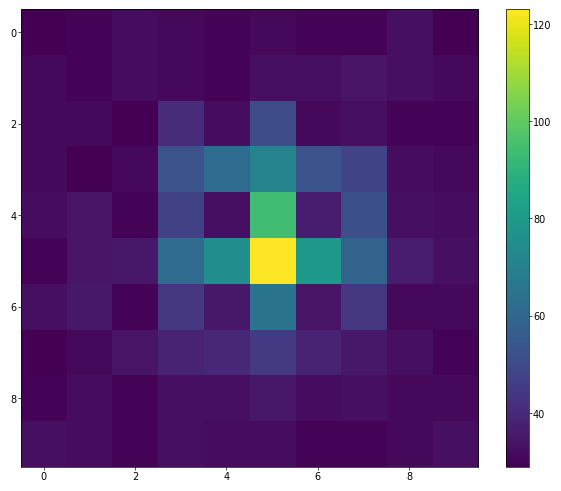

In [67]:
plt.imshow(bayer_image_example); plt.colorbar()

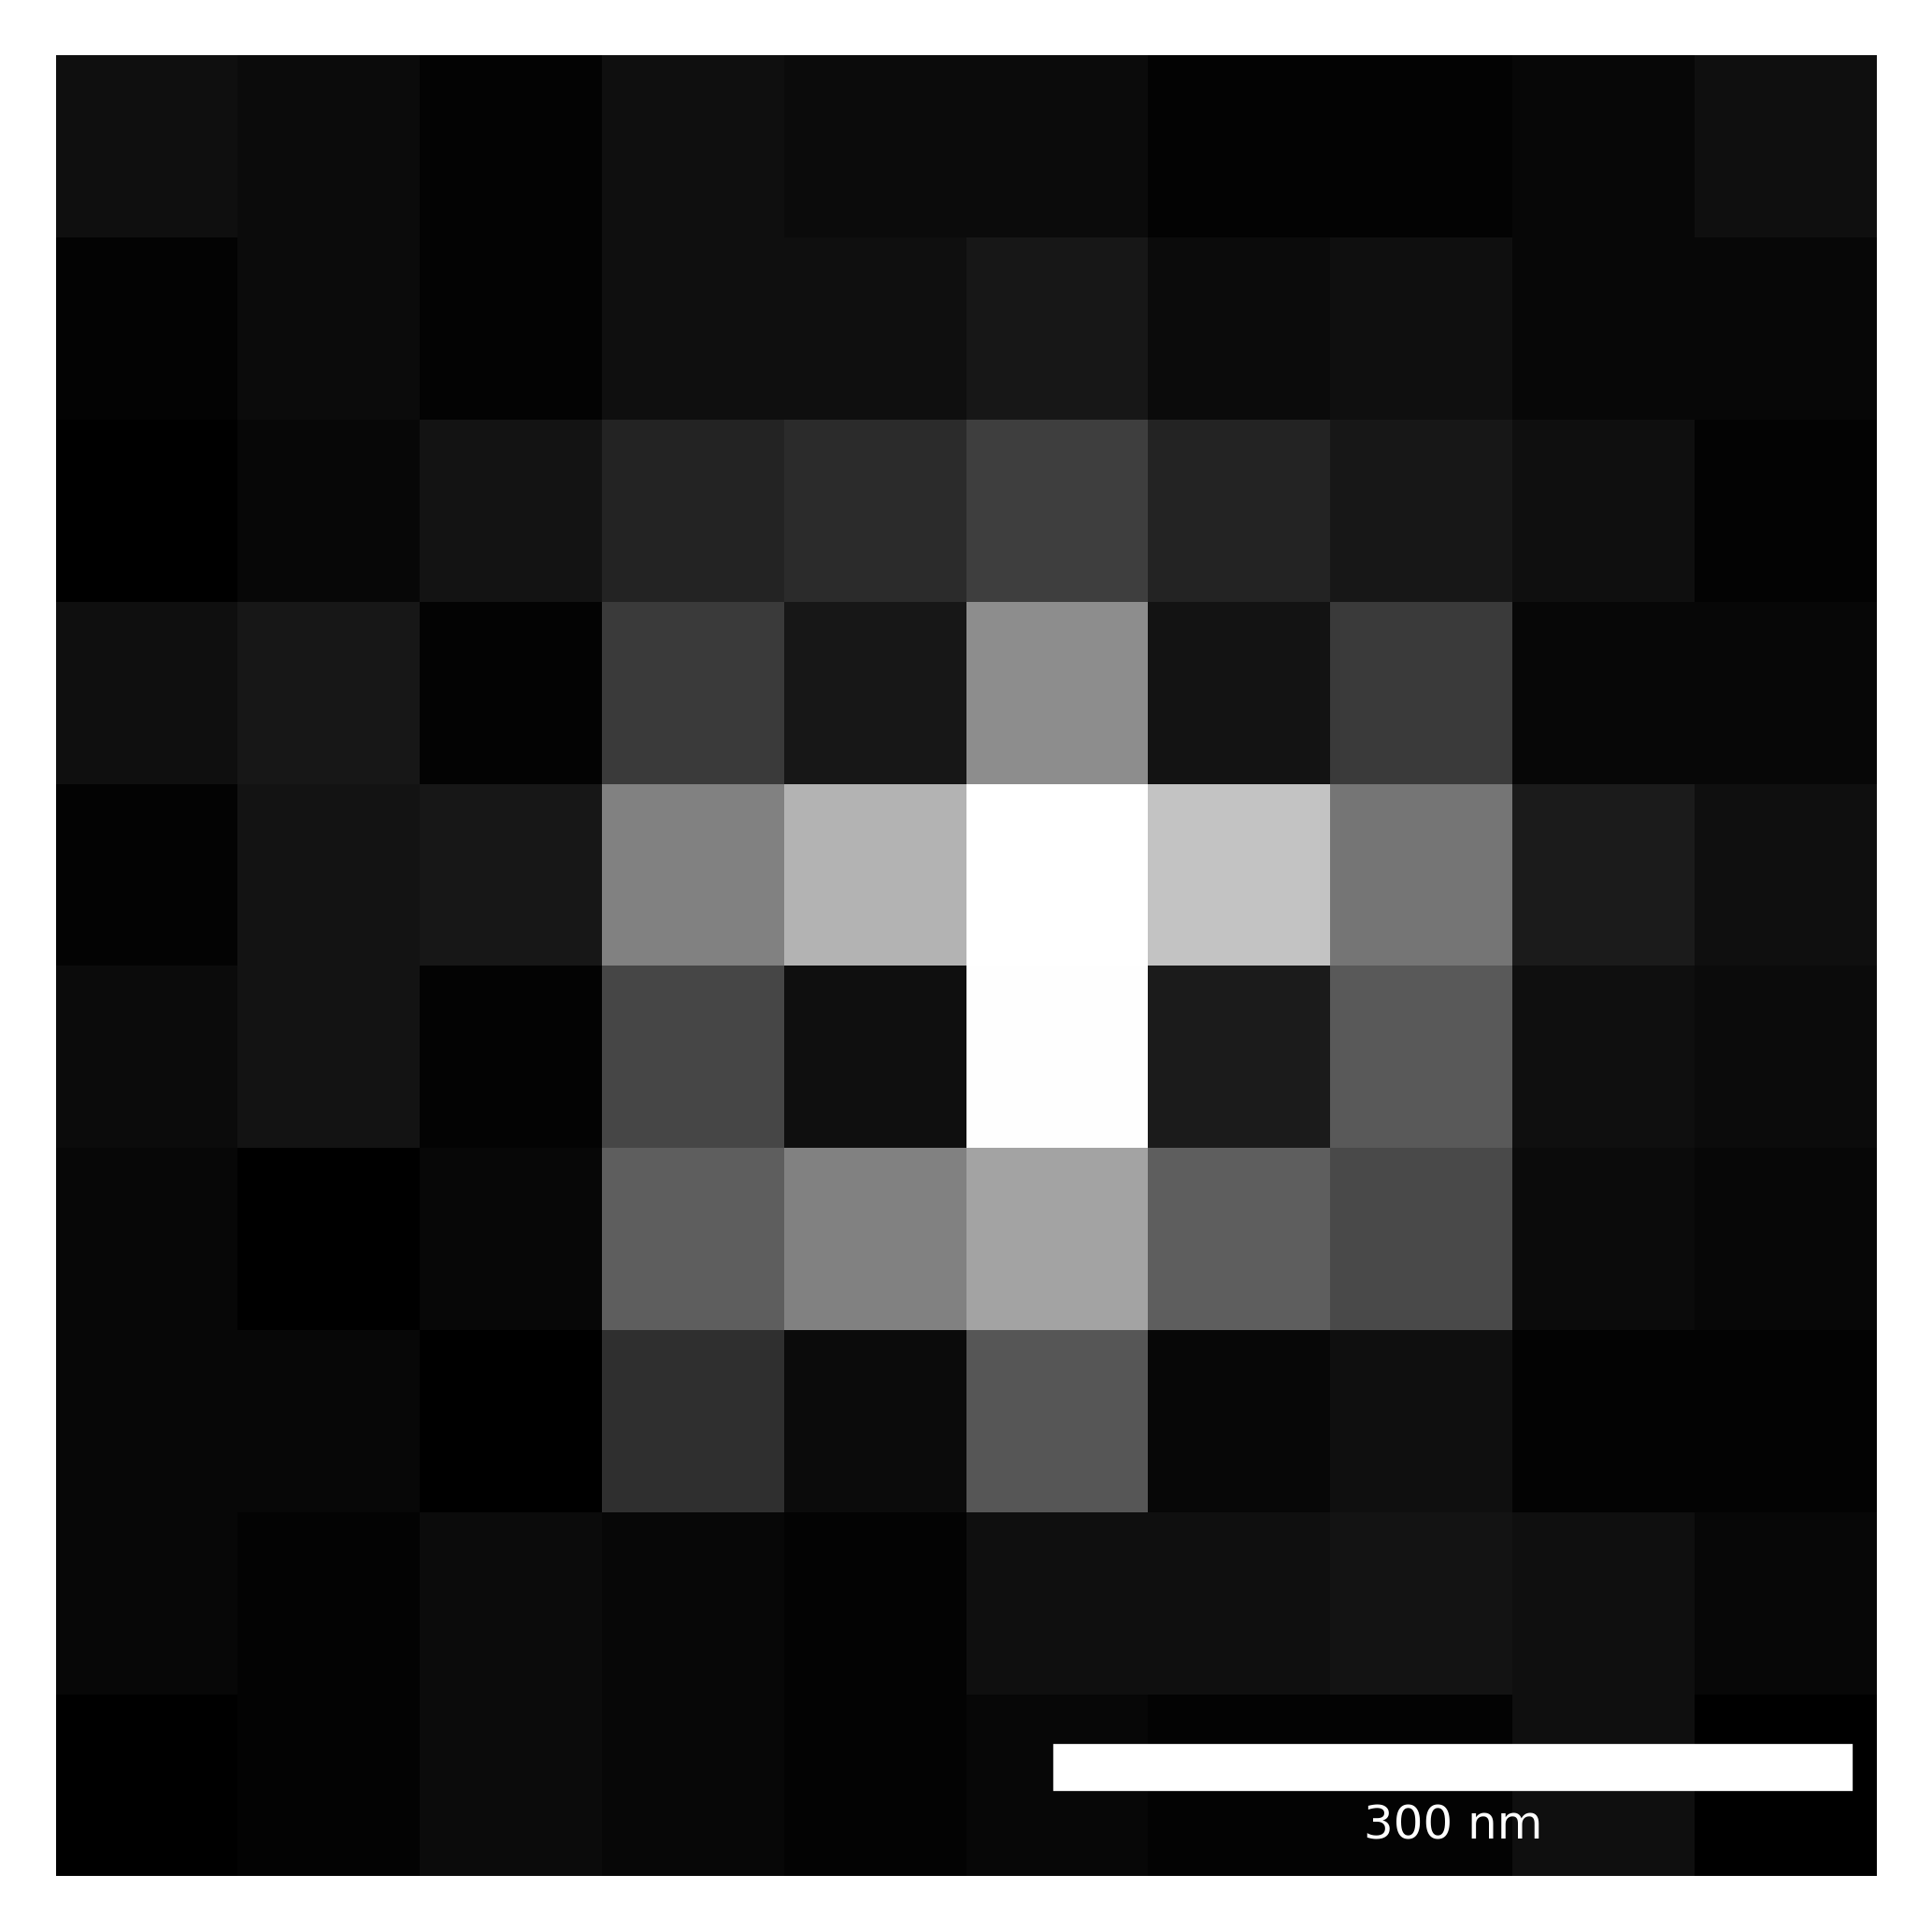

In [73]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image=bayer_image_example, pixelsize=69, colorbar=False, scalebarsize=300, scalebarlabel='300 nm', scalebar_color='white',
                        scalebar=True)
plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/ATTO_565_Exemplar.svg', dpi=600, format='svg')
plt.show()

In [75]:
loc_R = 200
loc_B = 100
loc_G = 300
size=300
photons_R = np.random.normal(loc=loc_R, scale=np.sqrt(loc_R), size=size)
photons_G = np.random.normal(loc=loc_G, scale=np.sqrt(loc_G), size=size)
photons_B = np.random.normal(loc=loc_B, scale=np.sqrt(loc_B), size=size)

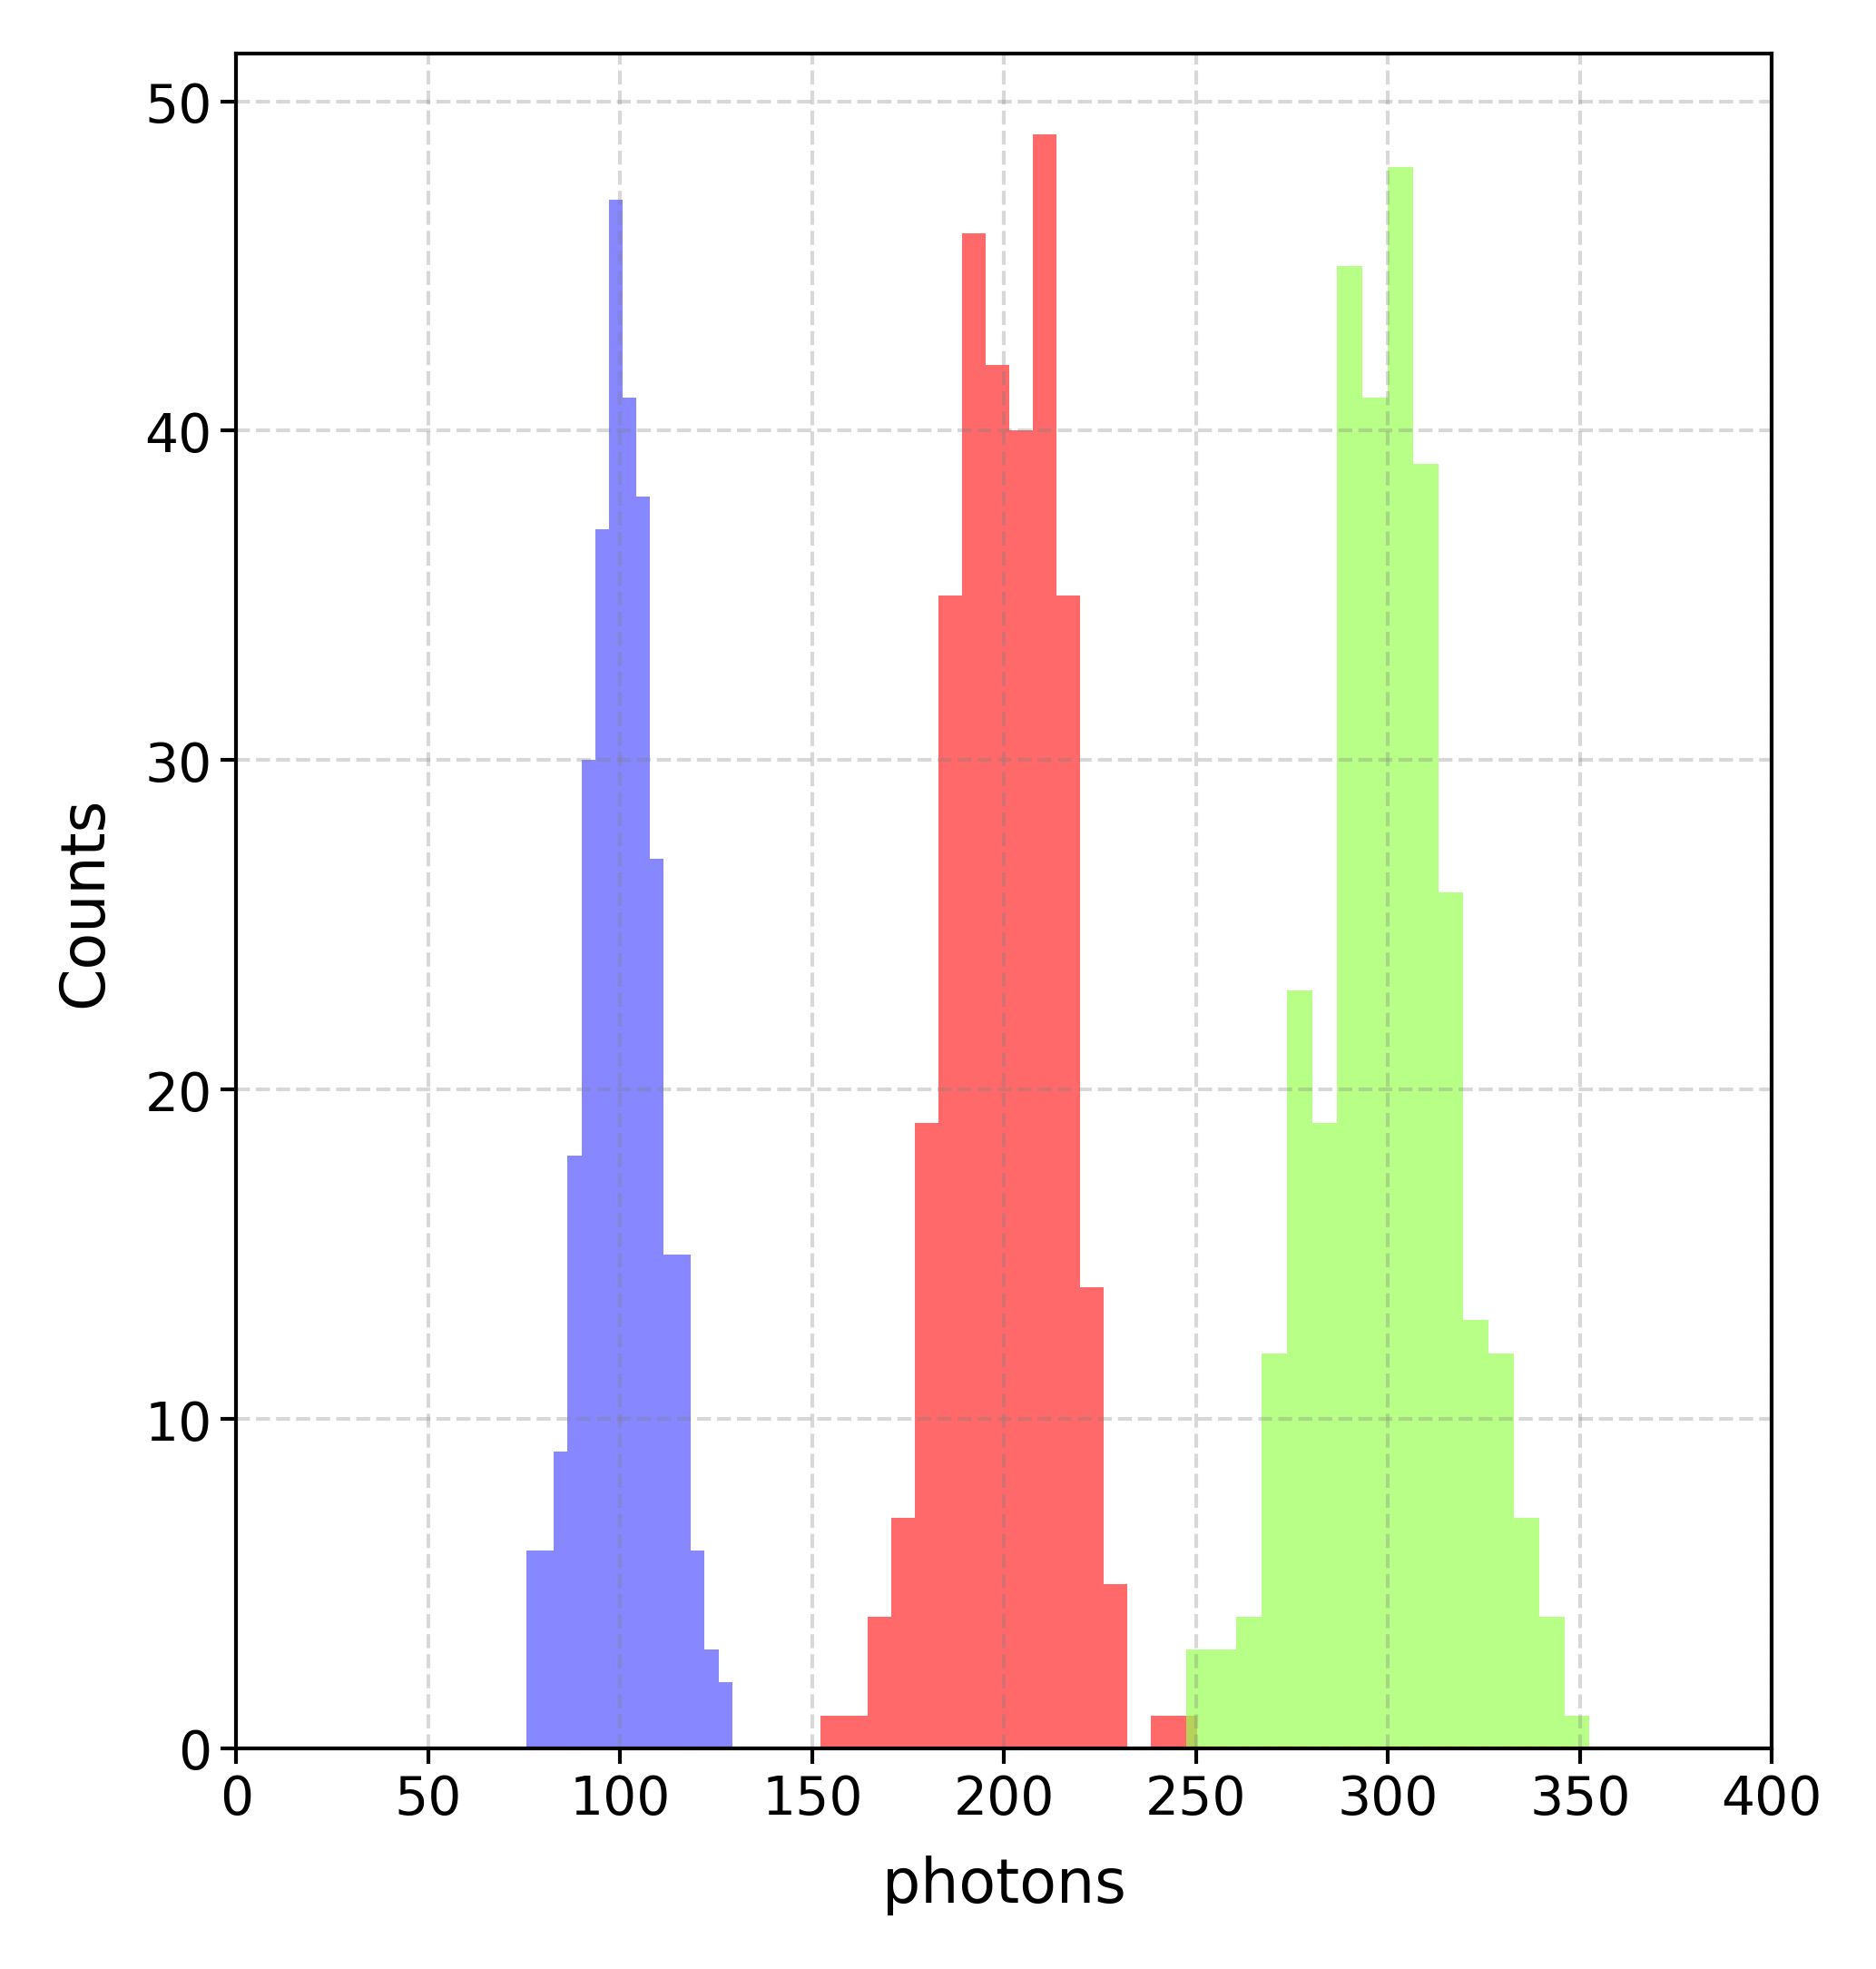

In [84]:
fig, axs = plotter.one_column_plot()

axs = plotter.histogram_plot(ax=axs, data=photons_R, bins=np.histogram_bin_edges(photons_R, 'fd'), color='#ff2a2a')
axs = plotter.histogram_plot(ax=axs, data=photons_B, bins=np.histogram_bin_edges(photons_B, 'fd'), color='#5555ff')
axs = plotter.histogram_plot(ax=axs, data=photons_G, bins=np.histogram_bin_edges(photons_G, 'fd'), color='#99ff55',
                            xlabel='photons')

axs.set_xlim([0, 400])
plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/histogram_exemplar.svg', dpi=600, format='svg')

plt.show()

In [85]:
photons = photons_R + photons_G + photons_B
ratio_R = photons_R/photons
ratio_G = photons_G/photons
ratio_B = photons_B/photons

/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/figure_notebooks/../src/PlottingBase.py:1637: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


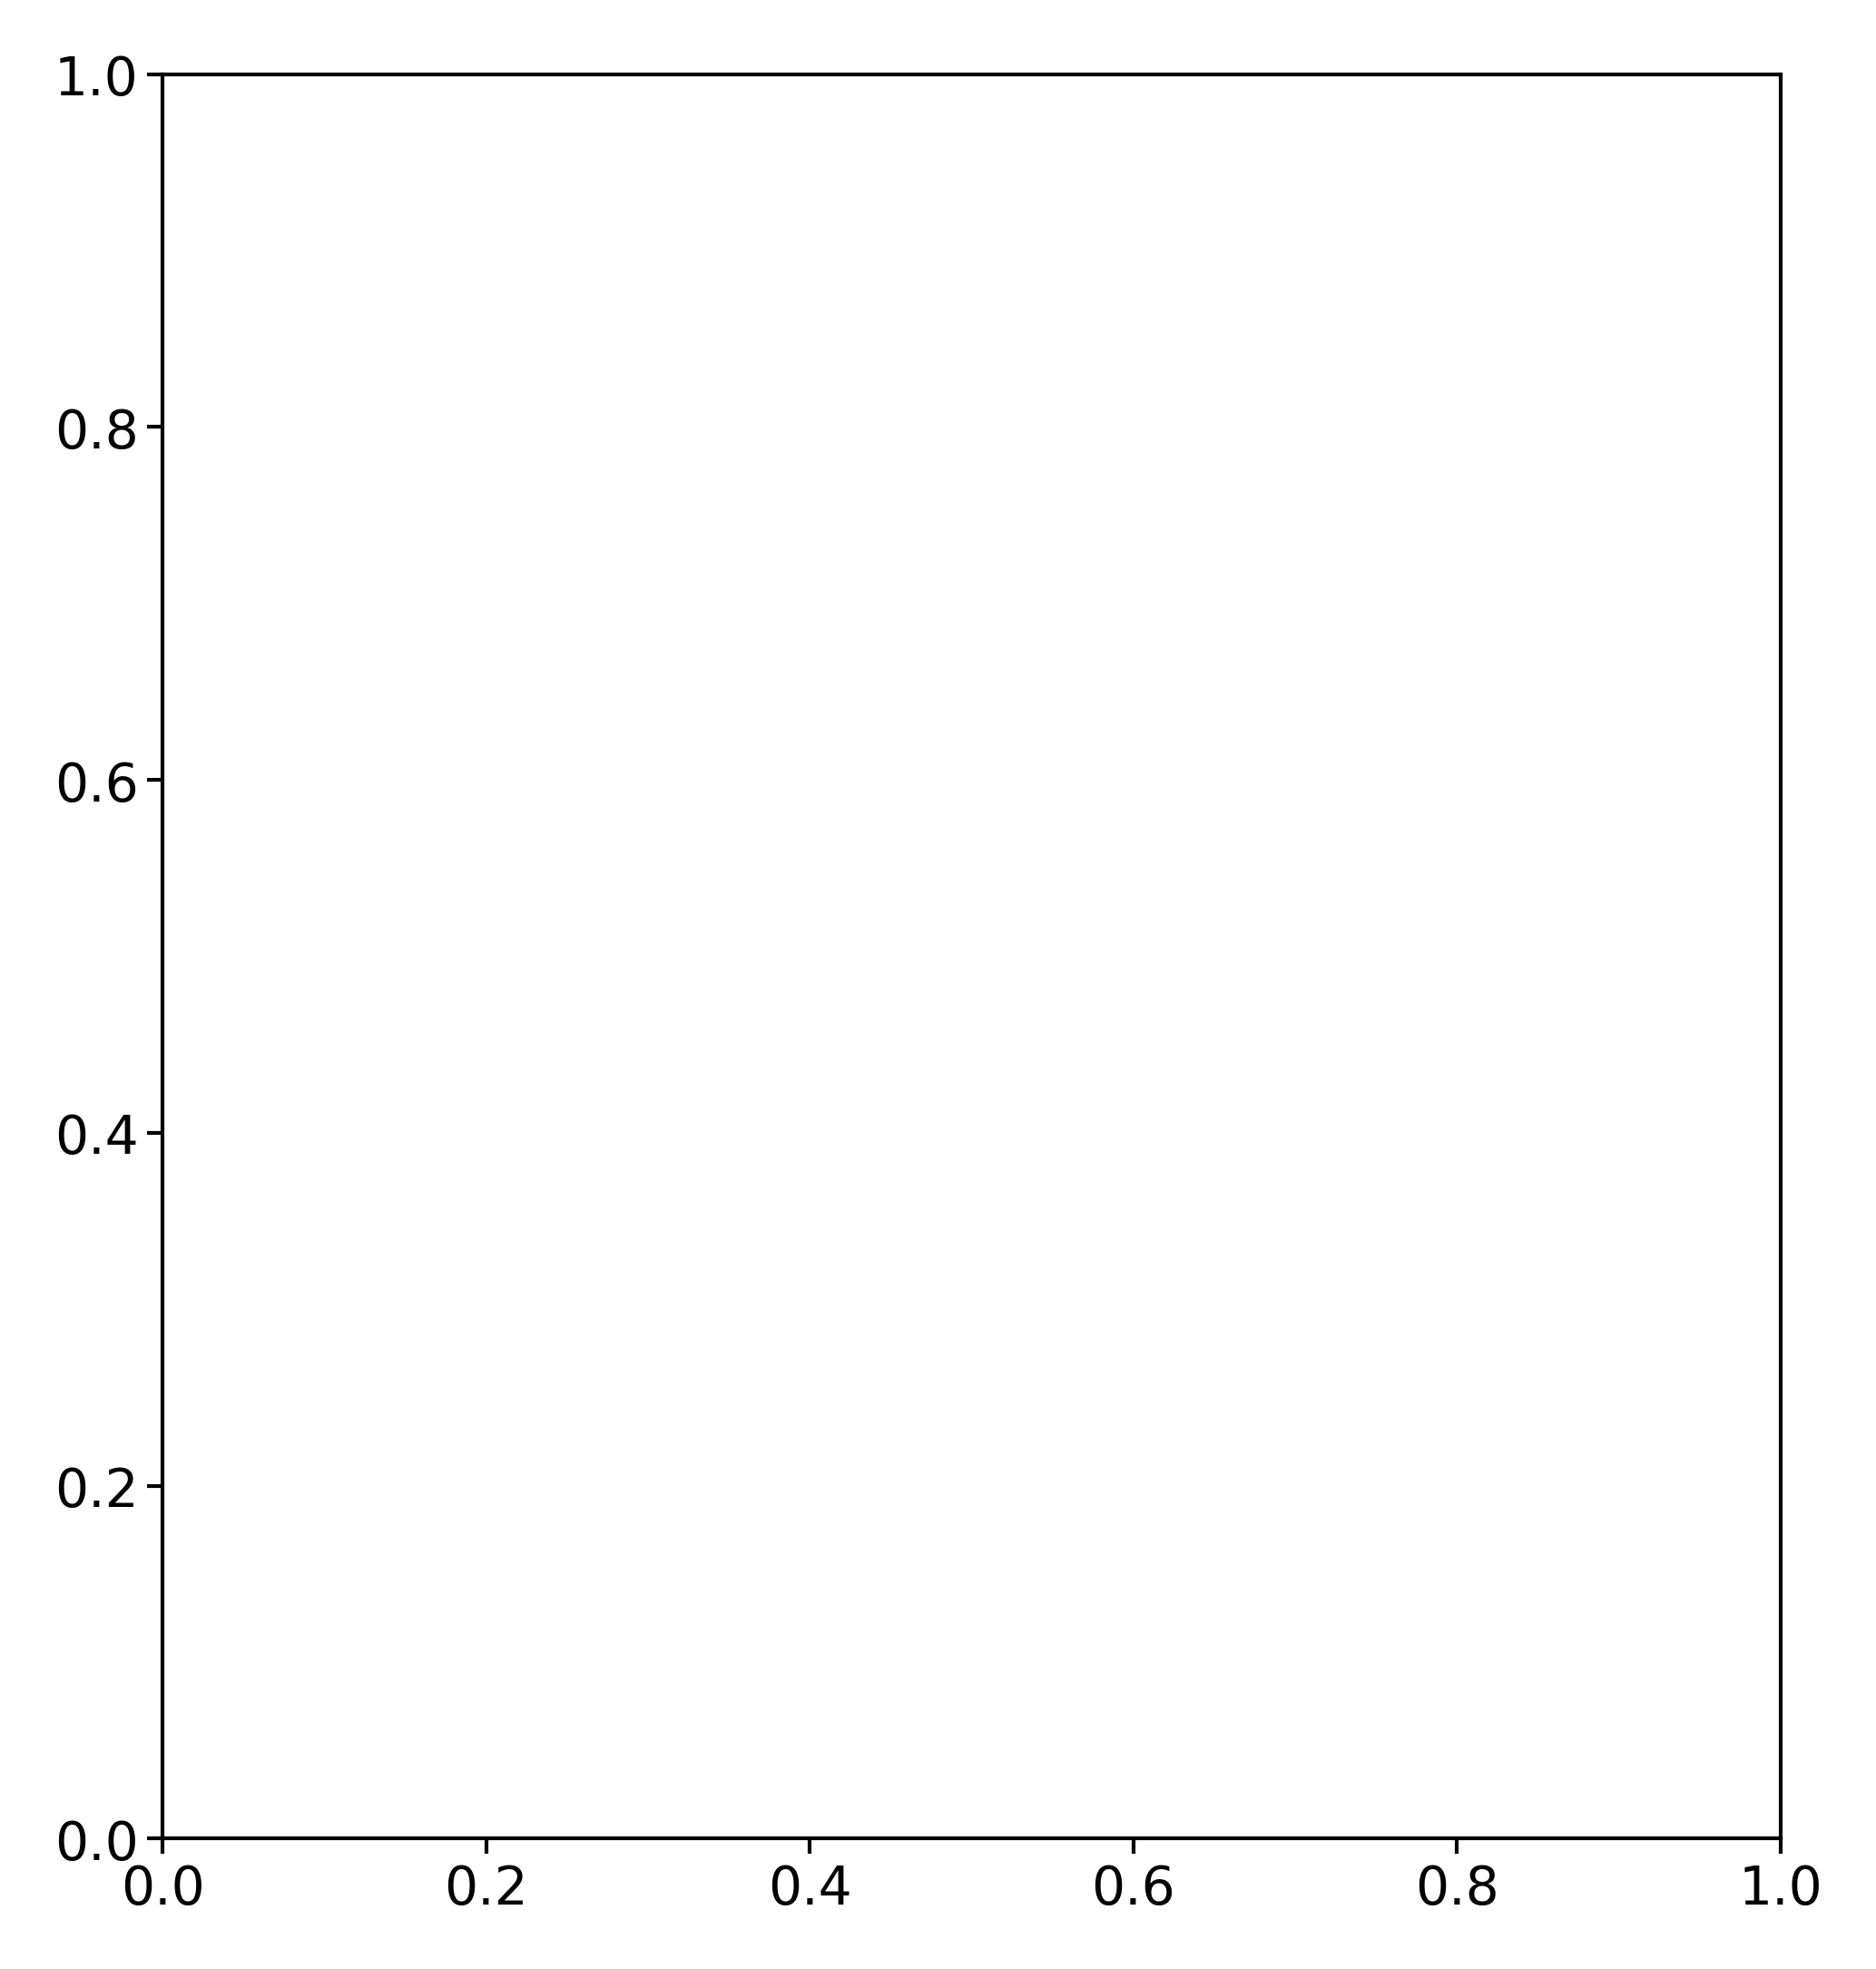

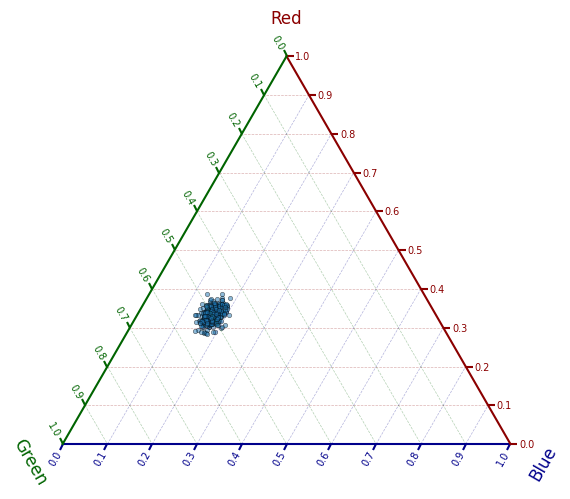

In [89]:
fig, ax = plotter.one_column_plot()

ax = plotter.create_ternary_plot(R=ratio_R, G=ratio_G, B=ratio_B)

plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/ternary.svg', dpi=600, format='svg')
